In [2]:
import os
import copy
import random
import numpy as np
import pandas as pd
import scipy.sparse as sp

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv

In [3]:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
GDRUG_PATH = "../data_2/Gdrug_eff.npy"              
GADR_PATH  = "../data_2/Gadr_filtered.npz"                   
LABELS_PATH = "../data_2/sider_lincs_labels_cid_filtered_by_gadr.csv"
DRUG_INDEX_PATH = "../data_2/drug_index.csv"
ADR_INDEX_PATH  = "../data_2/adr_index_filtered.csv"



In [5]:
Gdrug = np.load(GDRUG_PATH)
Gadr = sp.load_npz(GADR_PATH)

labels_df = pd.read_csv(LABELS_PATH)
drug_index_df = pd.read_csv(DRUG_INDEX_PATH)
adr_index_df = pd.read_csv(ADR_INDEX_PATH)

print("Gdrug shape:", Gdrug.shape)
print("Gadr shape :", Gadr.shape)
print("labels_df shape:", labels_df.shape)
print("drug_index_df shape:", drug_index_df.shape)
print("adr_index_df shape :", adr_index_df.shape)

print(labels_df["adr_id"].nunique())
print(len(adr_index_df))

Gdrug shape: (820, 978)
Gadr shape : (1347, 978)
labels_df shape: (57030, 8)
drug_index_df shape: (820, 2)
adr_index_df shape : (1347, 3)
1347
1347


In [6]:
num_drugs, num_genes = Gdrug.shape
num_adrs, num_genes_2 = Gadr.shape

assert num_genes == num_genes_2, "Gene dimension mismatch between Gdrug and Gadr"

print("num_drugs:", num_drugs)
print("num_genes:", num_genes)
print("num_adrs :", num_adrs)

num_drugs: 820
num_genes: 978
num_adrs : 1347


In [7]:
print("drug_index_df columns:", list(drug_index_df.columns))
print("adr_index_df columns :", list(adr_index_df.columns))
print("labels_df columns    :", list(labels_df.columns))

drug_index_df columns: ['drug_idx', 'pert_id']
adr_index_df columns : ['adr_idx', 'adr_id', 'adr_name']
labels_df columns    : ['drug_id', 'cid', 'drug_name', 'drug_name_norm_x', 'pert_id', 'pert_iname', 'adr_id', 'adr_name']


In [ ]:
DRUG_INDEX_COL = "drug_idx"     
DRUG_ID_COL    = "pert_id"      

# In adr_index.csv:
ADR_INDEX_COL  = "adr_idx"      
ADR_ID_COL     = "adr_id"

# In labels file:
LABEL_DRUG_COL = "pert_id"      
LABEL_ADR_COL  = "adr_id"

In [9]:
#  Build ID -> graph index maps

drug_id_to_idx = dict(zip(drug_index_df[DRUG_ID_COL], drug_index_df[DRUG_INDEX_COL]))
adr_id_to_idx  = dict(zip(adr_index_df[ADR_ID_COL], adr_index_df[ADR_INDEX_COL]))

print("num mapped drugs:", len(drug_id_to_idx))
print("num mapped adrs :", len(adr_id_to_idx))

num mapped drugs: 820
num mapped adrs : 1347


In [19]:
# Cell 9: Convert label table to graph index pairs

pairs_df = labels_df.copy()

pairs_df["drug_idx"] = pairs_df[LABEL_DRUG_COL].map(drug_id_to_idx)
pairs_df["adr_idx"]  = pairs_df[LABEL_ADR_COL].map(adr_id_to_idx)

before_drop = len(pairs_df)

pairs_df = pairs_df.dropna(subset=["drug_idx", "adr_idx"]).copy()
pairs_df["drug_idx"] = pairs_df["drug_idx"].astype(int)
pairs_df["adr_idx"]  = pairs_df["adr_idx"].astype(int)

pairs_df = pairs_df[["drug_idx", "adr_idx"]].drop_duplicates().reset_index(drop=True)

after_drop = len(pairs_df)

print("Pairs before mapping cleanup:", before_drop)
print("Pairs after mapping cleanup :", after_drop)
pairs_df.head()

Pairs before mapping cleanup: 57030
Pairs after mapping cleanup : 52898


,drug_idx,adr_idx
0,165,21
1,165,752
2,165,112
3,165,130
4,165,144


In [18]:
tmp = labels_df.copy()

tmp["drug_idx"] = tmp[LABEL_DRUG_COL].map(drug_id_to_idx)
tmp["adr_idx"] = tmp[LABEL_ADR_COL].map(adr_id_to_idx)

print("Original rows:", len(tmp))

print("\nNaNs after mapping:")
print(tmp[["drug_idx", "adr_idx"]].isna().sum())

tmp_no_na = tmp.dropna(subset=["drug_idx", "adr_idx"]).copy()
print("\nRows after dropna:", len(tmp_no_na))

tmp_no_na["drug_idx"] = tmp_no_na["drug_idx"].astype(int)
tmp_no_na["adr_idx"] = tmp_no_na["adr_idx"].astype(int)

num_unique_pairs = tmp_no_na[["drug_idx", "adr_idx"]].drop_duplicates().shape[0]
print("Unique mapped pairs:", num_unique_pairs)

print("\nDuplicate mapped rows removed:", len(tmp_no_na) - num_unique_pairs)

Original rows: 57030

NaNs after mapping:
drug_idx    0
adr_idx     0
dtype: int64

Rows after dropna: 57030
Unique mapped pairs: 52898

Duplicate mapped rows removed: 4132


#### all the rows dropped in graph index mapping are the duplicates. 

In [20]:
# Train / val / test split on positive pairs

positive_edges = pairs_df[["drug_idx", "adr_idx"]].values

train_pos, temp_pos = train_test_split(
    positive_edges,
    test_size=0.2,
    random_state=SEED
)

val_pos, test_pos = train_test_split(
    temp_pos,
    test_size=0.5,
    random_state=SEED
)

print("Train positives:", len(train_pos))
print("Val positives  :", len(val_pos))
print("Test positives :", len(test_pos))

Train positives: 42318
Val positives  : 5290
Test positives : 5290


In [21]:
# ============================================================
# Cell 11: Negative sampling
# ============================================================

positive_set = set(map(tuple, positive_edges.tolist()))

def sample_negative_edges(num_samples, num_drugs, num_adrs, positive_set, seed=42):
    rng = np.random.default_rng(seed)
    negatives = set()

    while len(negatives) < num_samples:
        d = rng.integers(0, num_drugs)
        a = rng.integers(0, num_adrs)

        if (d, a) not in positive_set:
            negatives.add((d, a))

    return np.array(list(negatives), dtype=np.int64)

train_neg = sample_negative_edges(len(train_pos), num_drugs, num_adrs, positive_set, seed=SEED+1)
val_neg   = sample_negative_edges(len(val_pos),   num_drugs, num_adrs, positive_set, seed=SEED+2)
test_neg  = sample_negative_edges(len(test_pos),  num_drugs, num_adrs, positive_set, seed=SEED+3)

print("Train negatives:", len(train_neg))
print("Val negatives  :", len(val_neg))
print("Test negatives :", len(test_neg))

Train negatives: 42318
Val negatives  : 5290
Test negatives : 5290


In [22]:
# ============================================================
# Cell 12: Helper to build edge-label tensors
# ============================================================

def make_edge_label_tensors(pos_edges, neg_edges):
    all_edges = np.vstack([pos_edges, neg_edges])
    labels = np.hstack([
        np.ones(len(pos_edges), dtype=np.float32),
        np.zeros(len(neg_edges), dtype=np.float32)
    ])

    edge_label_index = torch.tensor(all_edges.T, dtype=torch.long)
    edge_label = torch.tensor(labels, dtype=torch.float32)

    return edge_label_index, edge_label

train_edge_label_index, train_edge_label = make_edge_label_tensors(train_pos, train_neg)
val_edge_label_index, val_edge_label     = make_edge_label_tensors(val_pos, val_neg)
test_edge_label_index, test_edge_label   = make_edge_label_tensors(test_pos, test_neg)

print("train_edge_label_index shape:", train_edge_label_index.shape)
print("train_edge_label shape      :", train_edge_label.shape)

train_edge_label_index shape: torch.Size([2, 84636])
train_edge_label shape      : torch.Size([84636])


In [23]:
# ============================================================
# Cell 13: Build hetero graph structure
# Message-passing edges:
# drug -> gene
# gene -> drug
# adr  -> gene
# gene -> adr
# ============================================================

data = HeteroData()

data["drug"].num_nodes = num_drugs
data["gene"].num_nodes = num_genes
data["adr"].num_nodes  = num_adrs

# Use integer node IDs so we can learn embeddings for each node.
data["drug"].node_id = torch.arange(num_drugs)
data["gene"].node_id = torch.arange(num_genes)
data["adr"].node_id  = torch.arange(num_adrs)

# Drug-gene edges from nonzero entries in Gdrug
drug_rows, gene_cols = np.nonzero(Gdrug)

data["drug", "affects", "gene"].edge_index = torch.tensor(
    np.vstack([drug_rows, gene_cols]),
    dtype=torch.long
)

data["gene", "rev_affects", "drug"].edge_index = torch.tensor(
    np.vstack([gene_cols, drug_rows]),
    dtype=torch.long
)

# ADR-gene edges from sparse matrix Gadr (ADR x Gene)
adr_rows, gene_cols_2 = Gadr.nonzero()

data["adr", "associated_with", "gene"].edge_index = torch.tensor(
    np.vstack([adr_rows, gene_cols_2]),
    dtype=torch.long
)

data["gene", "rev_associated_with", "adr"].edge_index = torch.tensor(
    np.vstack([gene_cols_2, adr_rows]),
    dtype=torch.long
)

print(data)

HeteroData(
  drug={
    num_nodes=820,
    node_id=[820],
  },
  gene={
    num_nodes=978,
    node_id=[978],
  },
  adr={
    num_nodes=1347,
    node_id=[1347],
  },
  (drug, affects, gene)={ edge_index=[2, 801950] },
  (gene, rev_affects, drug)={ edge_index=[2, 801950] },
  (adr, associated_with, gene)={ edge_index=[2, 17481] },
  (gene, rev_associated_with, adr)={ edge_index=[2, 17481] }
)


In [24]:
# ============================================================
# Cell 14: Move graph and label tensors to device
# ============================================================

data = data.to(device)

train_edge_label_index = train_edge_label_index.to(device)
train_edge_label       = train_edge_label.to(device)

val_edge_label_index   = val_edge_label_index.to(device)
val_edge_label         = val_edge_label.to(device)

test_edge_label_index  = test_edge_label_index.to(device)
test_edge_label        = test_edge_label.to(device)

In [25]:
print(type(train_pos), train_pos.shape)
print(type(train_neg), train_neg.shape)
print(type(val_pos), val_pos.shape)
print(type(val_neg), val_neg.shape)
print(type(test_pos), test_pos.shape)
print(type(test_neg), test_neg.shape)

<class 'numpy.ndarray'> (42318, 2)
<class 'numpy.ndarray'> (42318, 2)
<class 'numpy.ndarray'> (5290, 2)
<class 'numpy.ndarray'> (5290, 2)
<class 'numpy.ndarray'> (5290, 2)
<class 'numpy.ndarray'> (5290, 2)


In [26]:
# ============================================================
# Cell 15: Define hetero GraphSAGE model
# ============================================================

class HeteroGraphSAGELinkPredictor(nn.Module):
    def __init__(self, num_drugs, num_genes, num_adrs, hidden_dim=64, dropout=0.2):
        super().__init__()

        # Learnable initial embeddings for each node type
        self.drug_emb = nn.Embedding(num_drugs, hidden_dim)
        self.gene_emb = nn.Embedding(num_genes, hidden_dim)
        self.adr_emb  = nn.Embedding(num_adrs, hidden_dim)

        self.conv1 = HeteroConv(
            {
                ("drug", "affects", "gene"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("gene", "rev_affects", "drug"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("adr", "associated_with", "gene"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("gene", "rev_associated_with", "adr"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
            },
            aggr="sum"
        )

        self.conv2 = HeteroConv(
            {
                ("drug", "affects", "gene"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("gene", "rev_affects", "drug"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("adr", "associated_with", "gene"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                ("gene", "rev_associated_with", "adr"): SAGEConv((hidden_dim, hidden_dim), hidden_dim),
            },
            aggr="sum"
        )

        self.dropout = nn.Dropout(dropout)

        # Decoder for drug-ADR pair scoring
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def encode(self, data):
        x_dict = {
            "drug": self.drug_emb(data["drug"].node_id),
            "gene": self.gene_emb(data["gene"].node_id),
            "adr":  self.adr_emb(data["adr"].node_id),
        }

        x_dict = self.conv1(x_dict, data.edge_index_dict)
        x_dict = {k: F.relu(v) for k, v in x_dict.items()}
        x_dict = {k: self.dropout(v) for k, v in x_dict.items()}

        x_dict = self.conv2(x_dict, data.edge_index_dict)
        x_dict = {k: F.relu(v) for k, v in x_dict.items()}

        return x_dict

    def decode(self, z_drug, z_adr, edge_label_index):
        drug_idx = edge_label_index[0]
        adr_idx  = edge_label_index[1]

        drug_vec = z_drug[drug_idx]
        adr_vec  = z_adr[adr_idx]

        pair_vec = torch.cat([drug_vec, adr_vec], dim=-1)
        logits = self.decoder(pair_vec).squeeze(-1)
        return logits

    def forward(self, data, edge_label_index):
        z_dict = self.encode(data)
        logits = self.decode(z_dict["drug"], z_dict["adr"], edge_label_index)
        return logits

In [27]:
# ============================================================
# Cell 16: Initialize model, optimizer, loss
# ============================================================

model = HeteroGraphSAGELinkPredictor(
    num_drugs=num_drugs,
    num_genes=num_genes,
    num_adrs=num_adrs,
    hidden_dim=64,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()

print(model)

HeteroGraphSAGELinkPredictor(
  (drug_emb): Embedding(820, 64)
  (gene_emb): Embedding(978, 64)
  (adr_emb): Embedding(1347, 64)
  (conv1): HeteroConv(num_relations=4)
  (conv2): HeteroConv(num_relations=4)
  (dropout): Dropout(p=0.2, inplace=False)
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [28]:
# ============================================================
# Cell 17: Evaluation function
# ============================================================

@torch.no_grad()
def evaluate_split(model, data, edge_label_index, edge_label, criterion):
    model.eval()

    logits = model(data, edge_label_index)
    probs = torch.sigmoid(logits)

    loss = criterion(logits, edge_label).item()

    y_true = edge_label.detach().cpu().numpy()
    y_prob = probs.detach().cpu().numpy()
    y_pred = (y_prob >= 0.5).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    ap  = average_precision_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)

    return {
        "loss": loss,
        "auc": auc,
        "ap": ap,
        "acc": acc
    }

In [29]:
# ============================================================
# Cell 18: Training loop
# ============================================================

NUM_EPOCHS = 50

best_val_ap = -1.0
best_state = None
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    logits = model(data, train_edge_label_index)
    loss = criterion(logits, train_edge_label)

    loss.backward()
    optimizer.step()

    train_metrics = evaluate_split(model, data, train_edge_label_index, train_edge_label, criterion)
    val_metrics   = evaluate_split(model, data, val_edge_label_index, val_edge_label, criterion)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_auc": train_metrics["auc"],
        "train_ap": train_metrics["ap"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_auc": val_metrics["auc"],
        "val_ap": val_metrics["ap"],
        "val_acc": val_metrics["acc"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_auc={train_metrics['auc']:.4f} | "
        f"train_ap={train_metrics['ap']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_auc={val_metrics['auc']:.4f} | "
        f"val_ap={val_metrics['ap']:.4f}"
    )

    if val_metrics["ap"] > best_val_ap:
        best_val_ap = val_metrics["ap"]
        best_state = copy.deepcopy(model.state_dict())

print("Best val AP:", best_val_ap)

Epoch 001 | train_loss=0.6931 | train_auc=0.5073 | train_ap=0.5157 | val_loss=0.6931 | val_auc=0.5086 | val_ap=0.5169
Epoch 002 | train_loss=0.6915 | train_auc=0.5507 | train_ap=0.5541 | val_loss=0.6915 | val_auc=0.5520 | val_ap=0.5563
Epoch 003 | train_loss=0.6902 | train_auc=0.5891 | train_ap=0.5908 | val_loss=0.6902 | val_auc=0.5910 | val_ap=0.5935
Epoch 004 | train_loss=0.6888 | train_auc=0.6205 | train_ap=0.6223 | val_loss=0.6888 | val_auc=0.6222 | val_ap=0.6247
Epoch 005 | train_loss=0.6870 | train_auc=0.6457 | train_ap=0.6482 | val_loss=0.6871 | val_auc=0.6468 | val_ap=0.6507
Epoch 006 | train_loss=0.6852 | train_auc=0.6658 | train_ap=0.6689 | val_loss=0.6852 | val_auc=0.6663 | val_ap=0.6714
Epoch 007 | train_loss=0.6832 | train_auc=0.6807 | train_ap=0.6847 | val_loss=0.6832 | val_auc=0.6811 | val_ap=0.6873
Epoch 008 | train_loss=0.6811 | train_auc=0.6913 | train_ap=0.6959 | val_loss=0.6811 | val_auc=0.6914 | val_ap=0.6986
Epoch 009 | train_loss=0.6787 | train_auc=0.6995 | train

In [30]:
# ============================================================
# Cell 19: Load best model and evaluate on test
# ============================================================

model.load_state_dict(best_state)

test_metrics = evaluate_split(model, data, test_edge_label_index, test_edge_label, criterion)

print("Final Test Metrics")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Final Test Metrics
loss: 0.4474
auc: 0.8762
ap: 0.8803
acc: 0.7999


In [31]:
# ============================================================
# Cell 20: Training history dataframe
# ============================================================

history_df = pd.DataFrame(history)
history_df.head()

,epoch,train_loss,train_auc,train_ap,train_acc,val_loss,val_auc,val_ap,val_acc
0,1,0.693056,0.507302,0.515670,0.505671,0.693061,0.508625,0.516910,0.501890
1,2,0.691496,0.550681,0.554125,0.529054,0.691511,0.551995,0.556337,0.529017
2,3,0.690221,0.589086,0.590822,0.537620,0.690230,0.591020,0.593469,0.536957
3,4,0.688753,0.620502,0.622319,0.548785,0.688759,0.622161,0.624708,0.550189
4,5,0.687048,0.645710,0.648159,0.572203,0.687053,0.646759,0.650747,0.571645


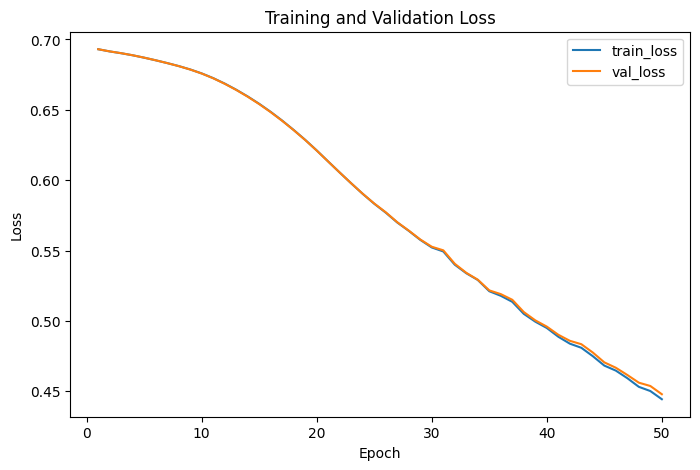

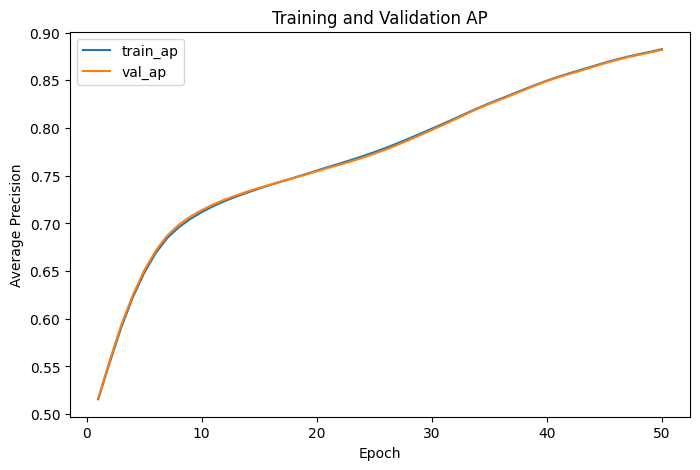

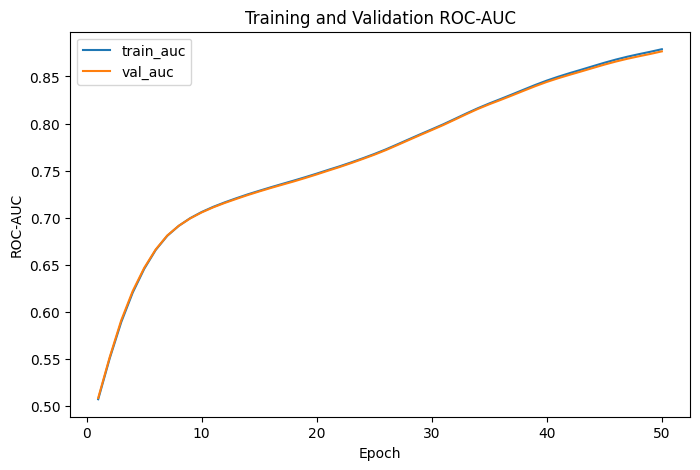

In [32]:
# ============================================================
# Cell 21: Plot training curves
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_ap"], label="train_ap")
plt.plot(history_df["epoch"], history_df["val_ap"], label="val_ap")
plt.xlabel("Epoch")
plt.ylabel("Average Precision")
plt.title("Training and Validation AP")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_auc"], label="train_auc")
plt.plot(history_df["epoch"], history_df["val_auc"], label="val_auc")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Training and Validation ROC-AUC")
plt.legend()
plt.show()

In [33]:
@torch.no_grad()
def get_node_embeddings(model, data):
    model.eval()
    z_dict = model.encode(data)
    return z_dict["drug"], z_dict["adr"]

In [34]:
@torch.no_grad()
def score_all_adrs_for_all_drugs(model, data, batch_size=128):
    """
    Returns a score matrix of shape [num_drugs, num_adrs].
    score_matrix[d, a] = model score for (drug d, adr a)
    """
    model.eval()

    z_drug, z_adr = get_node_embeddings(model, data)

    num_drugs = z_drug.size(0)
    num_adrs = z_adr.size(0)

    all_scores = []

    for start in range(0, num_drugs, batch_size):
        end = min(start + batch_size, num_drugs)

        # Drug embeddings for this batch
        drug_batch = z_drug[start:end]                         # [B, H]

        # Expand to all ADRs
        B = drug_batch.size(0)
        H = drug_batch.size(1)

        drug_expand = drug_batch.unsqueeze(1).expand(B, num_adrs, H)   # [B, A, H]
        adr_expand = z_adr.unsqueeze(0).expand(B, num_adrs, H)         # [B, A, H]

        pair_vec = torch.cat([drug_expand, adr_expand], dim=-1)        # [B, A, 2H]

        logits = model.decoder(pair_vec).squeeze(-1)                   # [B, A]
        probs = torch.sigmoid(logits)                                  # [B, A]

        all_scores.append(probs.detach().cpu())

    score_matrix = torch.cat(all_scores, dim=0).numpy()
    return score_matrix

In [35]:
def build_ground_truth_dict(edge_array):
    """
    edge_array: numpy array of shape [N, 2] with columns [drug_idx, adr_idx]
    Returns:
        {drug_idx: set_of_true_adr_indices}
    """
    gt = {}
    for d, a in edge_array:
        d = int(d)
        a = int(a)
        if d not in gt:
            gt[d] = set()
        gt[d].add(a)
    return gt

In [36]:
def recall_at_k(score_matrix, ground_truth_dict, k=10):
    """
    Computes macro Recall@K over drugs that have at least one true ADR.
    For each drug:
        Recall@K = (# true ADRs in top K) / (# true ADRs for that drug)
    Then average over drugs.
    """
    recalls = []

    for drug_idx, true_adrs in ground_truth_dict.items():
        if len(true_adrs) == 0:
            continue

        scores = score_matrix[drug_idx]
        topk_adrs = np.argpartition(-scores, k - 1)[:k]
        hits = len(set(topk_adrs).intersection(true_adrs))
        recalls.append(hits / len(true_adrs))

    return float(np.mean(recalls)) if recalls else 0.0

In [37]:
def hit_rate_at_k(score_matrix, ground_truth_dict, k=10):
    """
    HitRate@K:
    For each drug, did we recover at least one true ADR in the top K?
    """
    hits = []

    for drug_idx, true_adrs in ground_truth_dict.items():
        if len(true_adrs) == 0:
            continue

        scores = score_matrix[drug_idx]
        topk_adrs = np.argpartition(-scores, k - 1)[:k]
        hit = 1 if len(set(topk_adrs).intersection(true_adrs)) > 0 else 0
        hits.append(hit)

    return float(np.mean(hits)) if hits else 0.0

In [38]:
def mrr_score(score_matrix, ground_truth_dict):
    """
    Mean Reciprocal Rank:
    For each drug, find rank of first true ADR.
    """
    rr_list = []

    for drug_idx, true_adrs in ground_truth_dict.items():
        if len(true_adrs) == 0:
            continue

        scores = score_matrix[drug_idx]
        ranked_adrs = np.argsort(-scores)

        rr = 0.0
        for rank, adr_idx in enumerate(ranked_adrs, start=1):
            if adr_idx in true_adrs:
                rr = 1.0 / rank
                break

        rr_list.append(rr)

    return float(np.mean(rr_list)) if rr_list else 0.0

In [39]:
# Build score matrix for all drug-ADR pairs
score_matrix = score_all_adrs_for_all_drugs(model, data, batch_size=128)

print("score_matrix shape:", score_matrix.shape)

score_matrix shape: (820, 1347)


In [40]:
# Use only test positives as ground truth for ranking evaluation
test_gt = build_ground_truth_dict(test_pos)

print("Number of drugs with at least one test ADR:", len(test_gt))

Number of drugs with at least one test ADR: 743


In [41]:
r10 = recall_at_k(score_matrix, test_gt, k=10)
r25 = recall_at_k(score_matrix, test_gt, k=25)
r50 = recall_at_k(score_matrix, test_gt, k=50)

h10 = hit_rate_at_k(score_matrix, test_gt, k=10)
h25 = hit_rate_at_k(score_matrix, test_gt, k=25)
h50 = hit_rate_at_k(score_matrix, test_gt, k=50)

mrr = mrr_score(score_matrix, test_gt)

print(f"Recall@10 : {r10:.4f}")
print(f"Recall@25 : {r25:.4f}")
print(f"Recall@50 : {r50:.4f}")
print(f"HitRate@10: {h10:.4f}")
print(f"HitRate@25: {h25:.4f}")
print(f"HitRate@50: {h50:.4f}")
print(f"MRR       : {mrr:.4f}")

Recall@10 : 0.1265
Recall@25 : 0.2505
Recall@50 : 0.4085
HitRate@10: 0.4791
HitRate@25: 0.7389
HitRate@50: 0.8789
MRR       : 0.1737
